In [ ]:
# Load necessary libraries

import matplotlib.pyplot as plt
import numpy as np
import pathlib
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [55]:
# Set the path to the dataset directory

data_dir = pathlib.Path("dataset")
print(data_dir)

dataset


In [56]:
# Count the number of images in the dataset

image_count = len(list(data_dir.glob('*/*.jpg')))
print("Total images:", image_count)

Total images: 2527


In [57]:
# Get the class names from the dataset directory

class_names = [item.name for item in data_dir.glob('*') if item.is_dir()]
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


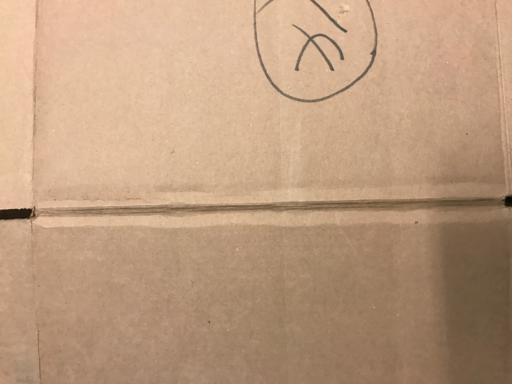

In [58]:
# Display an example image from the dataset

cardboard = list(data_dir.glob('cardboard/*'))

PIL.Image.open(str(cardboard[0]))

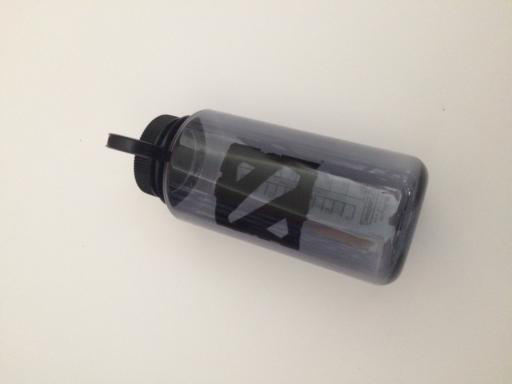

In [59]:
# Display another example image from the dataset

plastic = list(data_dir.glob('plastic/*'))

PIL.Image.open(str(plastic[0]))

In [60]:
# Define parameters for loading the dataset

batch_size = 32
img_height = 180
img_width = 180

In [61]:
# Create training dataset from the directory

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.


In [62]:
# Create validation dataset from the directory

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [63]:
# Get the class names from the training dataset

class_names = train_ds.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


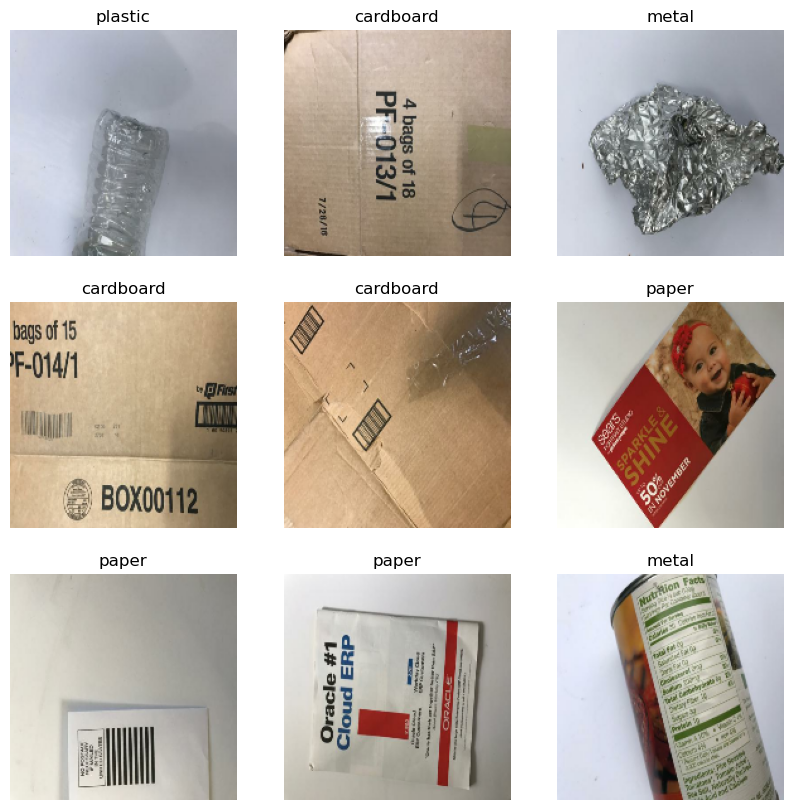

In [64]:
# Display some images from the training dataset

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [65]:
# Optimize the dataset performance

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [66]:
# Normalize the pixel values to the range [0, 1] from [0, 255]

normalization_layer = layers.Rescaling(1./255)

In [67]:
# Test the normalization layer on a batch of images

normalized_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

image_batch, labels_batch = next(iter(normalized_ds))

first_image = image_batch[0]

print(np.min(first_image), np.max(first_image))

0.0 0.98662305


In [68]:
# Build the CNN model

num_classes = len(class_names)

model = Sequential([
    
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    
    layers.Conv2D(16, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    
    layers.Dense(num_classes, activation='softmax')
])

c:\Users\hp\.conda\envs\Abdu\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [69]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [70]:
# Display the model summary

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,414 (15.22 MB)

 Trainable params: 3,989,414 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
# Train the model

epochs = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 260ms/step - accuracy: 0.3472 - loss: 1.6257 - val_accuracy: 0.3545 - val_loss: 1.5485
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 227ms/step - accuracy: 0.4782 - loss: 1.3155 - val_accuracy: 0.5465 - val_loss: 1.2409
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step - accuracy: 0.5851 - loss: 1.0876 - val_accuracy: 0.5822 - val_loss: 1.0901
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 224ms/step - accuracy: 0.6508 - loss: 0.9164 - val_accuracy: 0.5980 - val_loss: 1.0494
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 216ms/step - accuracy: 0.7478 - loss: 0.7064 - val_accuracy: 0.6337 - val_loss: 1.0151
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 215ms/step - accuracy: 0.8220 - loss: 0.5397 - val_accuracy: 0.6297 - val_loss: 1.0808
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - accuracy: 0.8318 - loss: 0.4944 - val_accuracy: 0.6614 - val_loss: 1.1477
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 219ms/step - accuracy: 0.8947 - loss: 0.3263 - val_accu

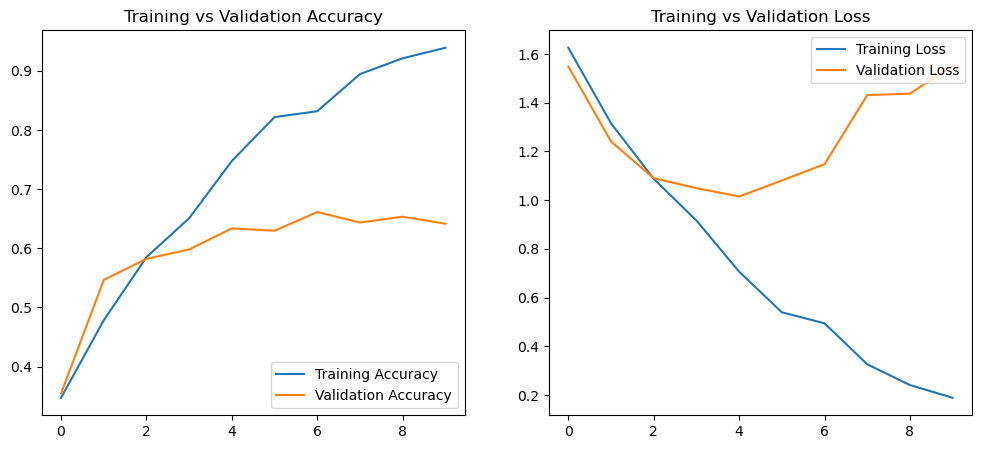

In [72]:
# Visualize training results (accuracy and loss)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss')

plt.show()

#### Fix Overfitting

In [73]:
# Data augmentation to improve model generalization

data_augmentation = keras.Sequential([
    
    layers.RandomFlip("horizontal",
                      input_shape=(img_height, img_width, 3)),
    
    layers.RandomRotation(0.1),
    
    layers.RandomZoom(0.1),
])

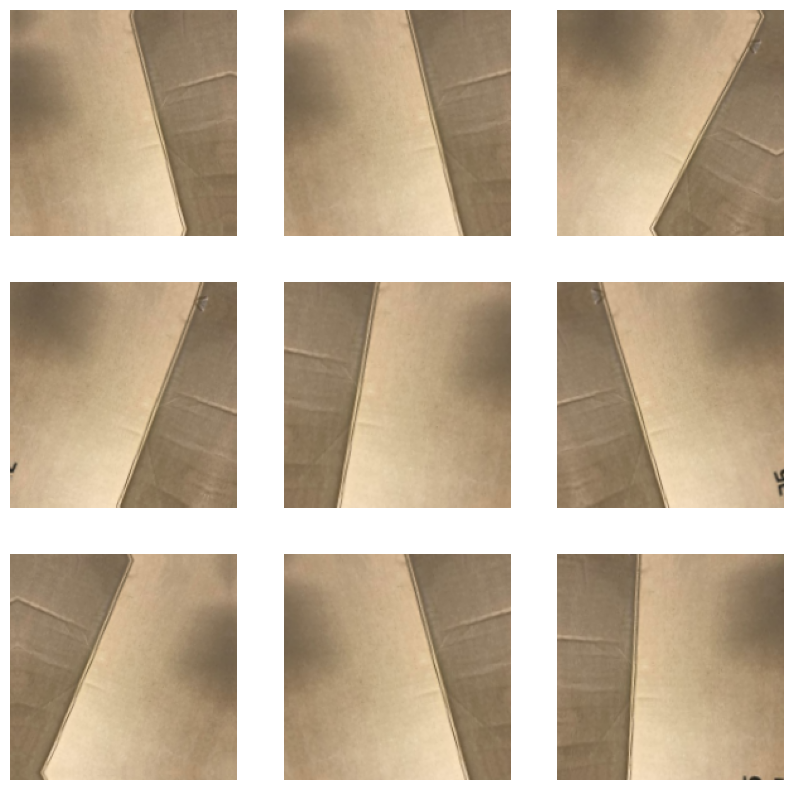

In [75]:
# Visualize some augmented images

plt.figure(figsize=(10,10))

for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        
        ax = plt.subplot(3,3,i+1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

In [76]:
# Build a new model that includes data augmentation and dropout for regularization

model = Sequential([
    
    data_augmentation,
    
    layers.Rescaling(1./255),
    
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Dropout(0.2),
    
    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    
    layers.Dense(num_classes, activation='softmax')
])

In [77]:
# Compile the improved model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [78]:
# Train the improved model

epochs = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/15


64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 305ms/step - accuracy: 0.2478 - loss: 1.7480 - val_accuracy: 0.3347 - val_loss: 1.5680
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 297ms/step - accuracy: 0.4026 - loss: 1.4573 - val_accuracy: 0.4139 - val_loss: 1.4170
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 306ms/step - accuracy: 0.4575 - loss: 1.3292 - val_accuracy: 0.4594 - val_loss: 1.3398
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 312ms/step - accuracy: 0.5183 - loss: 1.2330 - val_accuracy: 0.5446 - val_loss: 1.2345
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 297ms/step - accuracy: 0.5613 - loss: 1.1558 - val_accuracy: 0.5446 - val_loss: 1.2144
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 283ms/step - accuracy: 0.5658 - loss: 1.1380 - val_accuracy: 0.6178 - val_loss: 1.0820
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 286ms/step - accuracy: 0.5885 - loss: 1.0727 - val_accuracy: 0.5802 - val_loss: 1.1110
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 281ms/step - accuracy: 0.6128 - loss: 1.0080 - val_accuracy: 0.564

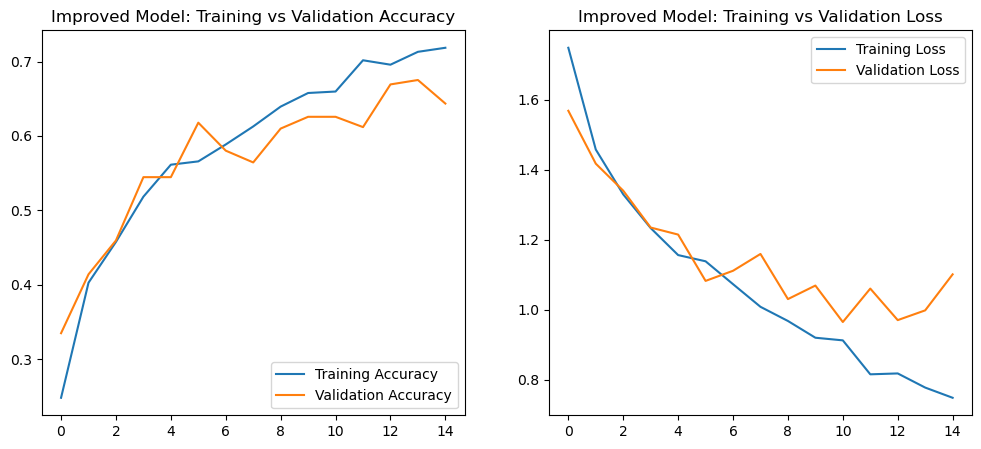

In [79]:
# Plot training results for the improved model (accuracy and loss)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Improved Model: Training vs Validation Accuracy')

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Improved Model: Training vs Validation Loss')

plt.show()

In [80]:
# Test the model on a new image

img_path = "dataset/test1.jpg"

In [81]:
img = tf.keras.utils.load_img(
    img_path,
    target_size=(img_height, img_width)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)

score = predictions[0]

predicted_class = class_names[np.argmax(score)]

print("Predicted Class:", predicted_class)
print("Confidence:", np.max(score) * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: paper
Confidence: 63.03678


#### Apply transfer Learning to improve the model accuracy more

In [82]:
# Save the trained model for future use

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [83]:
# Load the pretrained base model

base_model = MobileNetV2(
    input_shape=(180, 180, 3),
    include_top=False,
    weights='imagenet'
)

C:\Users\hp\AppData\Local\Temp\ipykernel_22580\1813964765.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [84]:
# freeze the pretrained base model

base_model.trainable = False

In [86]:
# Build the transfer learning model 

transfer_model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

In [87]:
# Compile the transfer learning model

transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [88]:
# Display the transfer learning model summary

transfer_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [89]:
# Train the transfer learning model

epochs = 10

history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 633ms/step - accuracy: 0.4951 - loss: 1.3164 - val_accuracy: 0.6772 - val_loss: 0.8215
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 574ms/step - accuracy: 0.6954 - loss: 0.8130 - val_accuracy: 0.7307 - val_loss: 0.7199
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 549ms/step - accuracy: 0.7295 - loss: 0.7173 - val_accuracy: 0.7683 - val_loss: 0.6068
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 571ms/step - accuracy: 0.7695 - loss: 0.6253 - val_accuracy: 0.7703 - val_loss: 0.5834
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 549ms/step - accuracy: 0.7715 - loss: 0.6033 - val_accuracy: 0.8119 - val_loss: 0.5532
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 537ms/step - accuracy: 0.8017 - loss: 0.5505 - val_accuracy: 0.7960 - val_loss: 0.5467
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 562ms/step - accuracy: 0.8042 - loss: 0.5302 - val_accuracy: 0.8059 - val_loss: 0.5469
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 522ms/step - accuracy: 0.8175 - loss: 0.5064 - val_accu

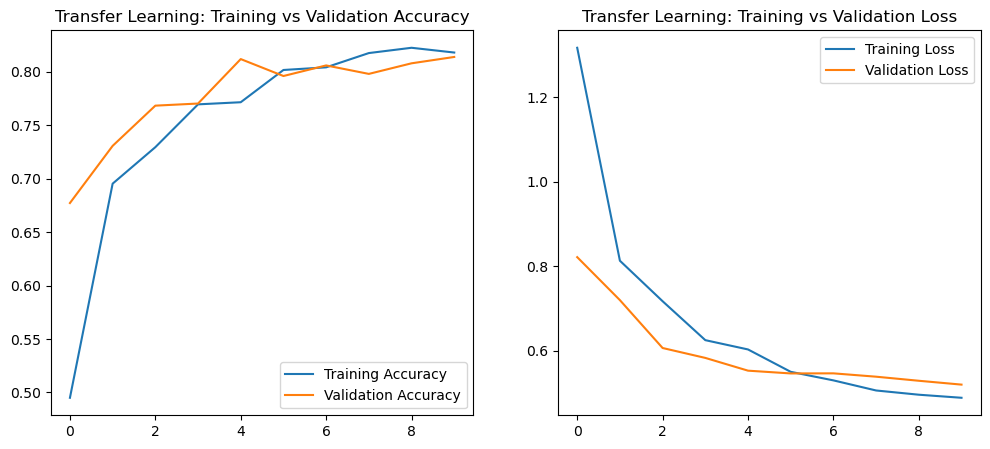

In [90]:
# Plot training results for the transfer learning model (accuracy and loss)

acc = history_transfer.history['accuracy']
val_acc = history_transfer.history['val_accuracy']

loss = history_transfer.history['loss']
val_loss = history_transfer.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Transfer Learning: Training vs Validation Accuracy')

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Transfer Learning: Training vs Validation Loss')

plt.show()

In [91]:
# Test the model on a new image

img_path = "dataset/test1.jpg"

In [92]:
# Load and preprocess the image for prediction

img = tf.keras.utils.load_img(
    img_path,
    target_size=(img_height, img_width)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = transfer_model.predict(img_array)

predicted_class = class_names[np.argmax(predictions[0])]
confidence = np.max(predictions[0]) * 100

print("Predicted Class:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Class: glass
Confidence: 73.27333


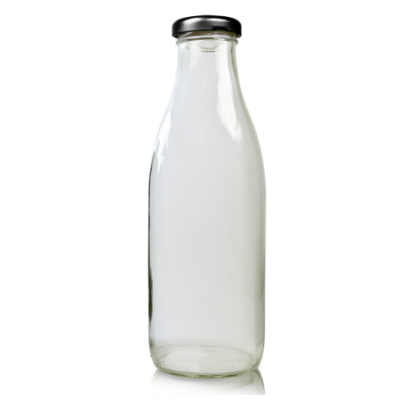

In [93]:
# Display the test image

img = tf.keras.utils.load_img(img_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [95]:
# Test the model on another new image

img_path_2 = "dataset/test2.jfif"

In [96]:
# Load and preprocess the image for prediction

img = tf.keras.utils.load_img(
    img_path_2,
    target_size=(img_height, img_width)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = transfer_model.predict(img_array)

predicted_class = class_names[np.argmax(predictions[0])]
confidence = np.max(predictions[0]) * 100

print("Predicted Class:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predicted Class: paper
Confidence: 90.895744


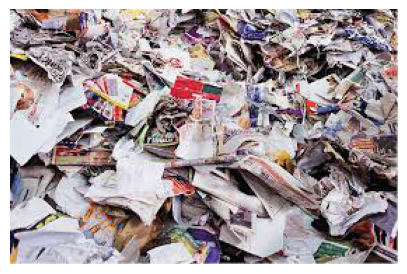

In [97]:
# Display the test image

img = tf.keras.utils.load_img(img_path_2)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [99]:
# Test the model on a third new image

img_path_3 = "dataset/test3.jpg"

In [100]:
# Load and preprocess the image for prediction

img = tf.keras.utils.load_img(
    img_path_3,
    target_size=(img_height, img_width)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = transfer_model.predict(img_array)

predicted_class = class_names[np.argmax(predictions[0])]
confidence = np.max(predictions[0]) * 100

print("Predicted Class:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted Class: metal
Confidence: 88.96601


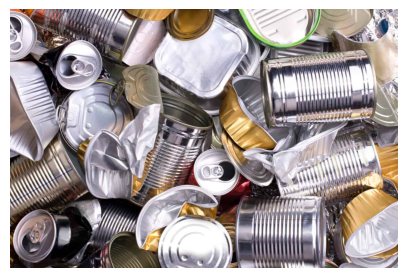

In [101]:
# Display the test image

img = tf.keras.utils.load_img(img_path_3)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [103]:
# Save the model
transfer_model.save("garbage_classifier.h5")